# EDA Precision Lab — Real Relationships vs. Real Comparisons

**Goal:** Fix two specific mistakes — mislabeling a comparison chart as a relationship chart, and stating numbers that don't match fresh computation. Build both chart types correctly, compute real correlations (including a null one), and verify every claimed number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.__version__, np.__version__

('2.3.3', '2.2.6')

## Part A: Build the dataset

Generated from a fixed spec, unmodified — built so the relationships in it are known in advance, which lets us check our own work today.

In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

students.shape

(600, 6)

In [3]:
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


## Part B: Genuine relationships, correctly built and correctly written up

### Step 2: Real relationship chart — study hours vs. exam score

A relationship chart compares two continuous numeric variables that could plausibly vary together. The concrete test: if the x-axis values were shuffled, would the chart still mean the same thing? Here, no — position on the x-axis (hours studied) is itself meaningful, so this is a genuine relationship chart, not a comparison.

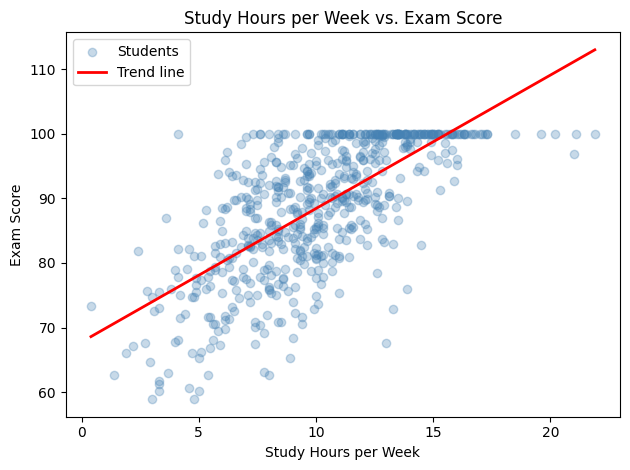

Pearson correlation (study hours vs exam score): r = 0.689, p = 0.0000


In [4]:
correlation_study, p_value_study = stats.pearsonr(students['study_hours_per_week'], students['exam_score'])

# Fit a trend line
coeffs = np.polyfit(students['study_hours_per_week'], students['exam_score'], 1)
trend_line = np.poly1d(coeffs)
x_range = np.linspace(students['study_hours_per_week'].min(), students['study_hours_per_week'].max(), 100)

fig, ax = plt.subplots()
ax.scatter(students['study_hours_per_week'], students['exam_score'], alpha=0.3, color='steelblue', label='Students')
ax.plot(x_range, trend_line(x_range), color='red', linewidth=2, label='Trend line')

ax.set_title('Study Hours per Week vs. Exam Score')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Exam Score')
ax.legend()

fig.tight_layout()
plt.show()

print(f"Pearson correlation (study hours vs exam score): r = {correlation_study:.3f}, p = {p_value_study:.4f}")

**Finding:** Study hours per week and exam score show a positive relationship, r = 0.689 — students who study more hours per week tend to score noticeably higher on the exam, consistent with the trend line's upward slope. This is a strong correlation, and the very low p-value (p < 0.0001) indicates the relationship is highly unlikely to be due to random chance.

### Step 3: Null-relationship chart — sleep hours vs. exam score

Same relationship test applies: two continuous variables, x-axis position is meaningful. This chart is built and written up the same way as step 2, regardless of what the correlation turns out to be.

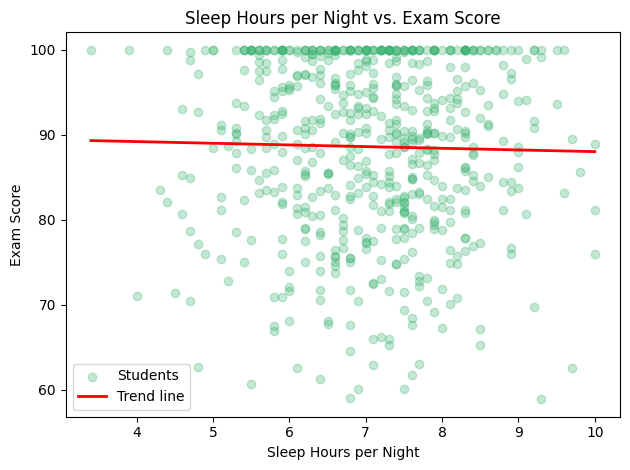

Pearson correlation (sleep hours vs exam score): r = -0.022, p = 0.5965


In [5]:
correlation_sleep, p_value_sleep = stats.pearsonr(students['sleep_hours_per_night'], students['exam_score'])

coeffs_sleep = np.polyfit(students['sleep_hours_per_night'], students['exam_score'], 1)
trend_line_sleep = np.poly1d(coeffs_sleep)
x_range_sleep = np.linspace(students['sleep_hours_per_night'].min(), students['sleep_hours_per_night'].max(), 100)

fig, ax = plt.subplots()
ax.scatter(students['sleep_hours_per_night'], students['exam_score'], alpha=0.3, color='mediumseagreen', label='Students')
ax.plot(x_range_sleep, trend_line_sleep(x_range_sleep), color='red', linewidth=2, label='Trend line')

ax.set_title('Sleep Hours per Night vs. Exam Score')
ax.set_xlabel('Sleep Hours per Night')
ax.set_ylabel('Exam Score')
ax.legend()

fig.tight_layout()
plt.show()

print(f"Pearson correlation (sleep hours vs exam score): r = {correlation_sleep:.3f}, p = {p_value_sleep:.4f}")

**Finding:** Sleep hours per night show no meaningful relationship with exam score in this dataset, r = -0.022. The correlation is close enough to zero, and the p-value (p = 0.597) is far above any standard significance threshold, to conclude that sleep hours and exam performance do not move together here — this is a real, reportable result, not an absence of a finding.

### Step 4: Real comparison chart — exam score by section

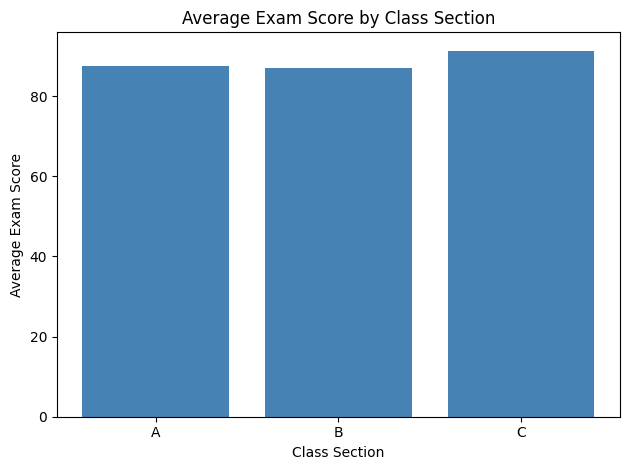

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


In [6]:
mean_score_by_section = students.groupby('class_section')['exam_score'].mean().reindex(['A', 'B', 'C'])

fig, ax = plt.subplots()
ax.bar(mean_score_by_section.index, mean_score_by_section.values, color='steelblue')

ax.set_title('Average Exam Score by Class Section')
ax.set_xlabel('Class Section')
ax.set_ylabel('Average Exam Score')

fig.tight_layout()
plt.show()

print(mean_score_by_section)

**Why this is a comparison chart, not a relationship chart:** Using the shuffle test — if the sections were reordered (say, C, A, B instead of A, B, C), the chart would still convey exactly the same information, since section is a category with no inherent numeric order between A, B, and C. This makes it a categorical comparison, not a relationship, even though it's plotted as a bar chart showing numeric averages.

## Part C: The trap, and the audit

### Step 5: Build the trap on purpose — line chart connecting section averages

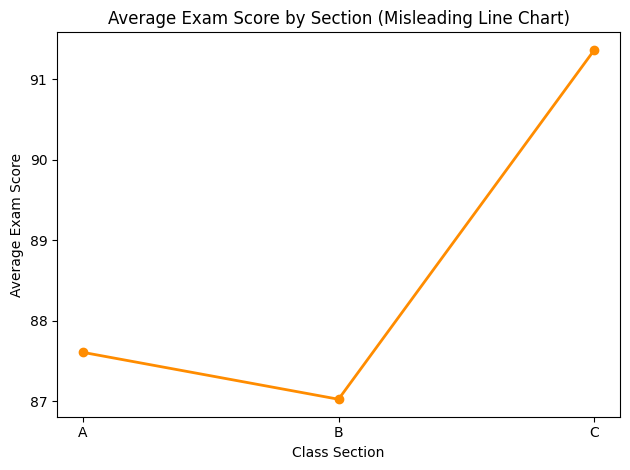

In [7]:
fig, ax = plt.subplots()
ax.plot(mean_score_by_section.index, mean_score_by_section.values, marker='o', color='darkorange', linewidth=2)

ax.set_title('Average Exam Score by Section (Misleading Line Chart)')
ax.set_xlabel('Class Section')
ax.set_ylabel('Average Exam Score')

fig.tight_layout()
plt.show()

**False impression this creates:** Connecting A → B → C with a line visually implies a trend or a path — as if a student's score would gradually shift while "moving through" the sections in order, dipping from A to B before rising sharply to C. But there is no "in-between" state connecting these categories; a student is in exactly one section, not partway between two. The bar chart in step 4 correctly shows three independent averages with no implied movement between them, while this line chart manufactures a rise-then-fall narrative that doesn't exist in the data.

### Step 6: Break the layout on purpose, then fix it

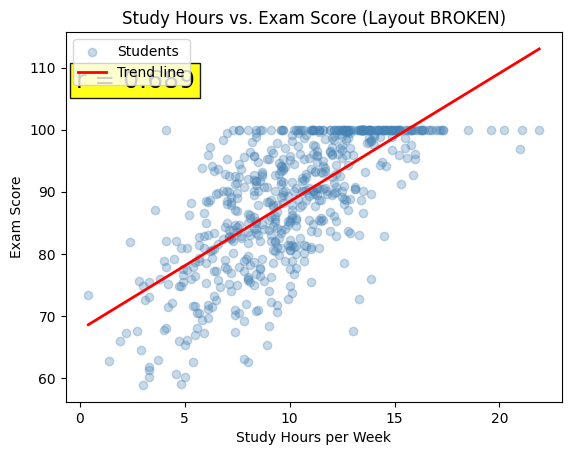

In [11]:
fig, ax = plt.subplots()
ax.scatter(students['study_hours_per_week'], students['exam_score'], alpha=0.3, color='steelblue', label='Students')
ax.plot(x_range, trend_line(x_range), color='red', linewidth=2, label='Trend line')

ax.set_title('Study Hours vs. Exam Score (Layout BROKEN)')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Exam Score')
ax.legend(loc='upper left')

# Positioned using axes-fraction coordinates, directly inside the legend's own space
ax.text(0.02, 0.85, f'r = {correlation_study:.3f}', fontsize=18, color='black',
        transform=ax.transAxes,
        bbox=dict(facecolor='yellow', alpha=0.9))

fig.savefig('chart_broken_layout.png', dpi=150)
plt.show()

Saved as `chart_broken_layout.png` — opening the actual file (not just the inline preview) confirms the yellow annotation box sits directly on top of the legend, making both unreadable where they overlap.

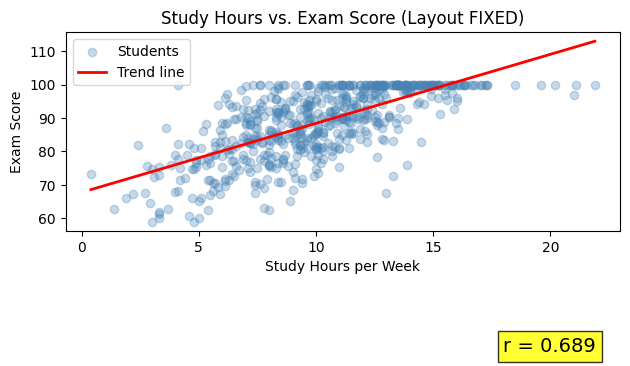

In [9]:
fig, ax = plt.subplots()
ax.scatter(students['study_hours_per_week'], students['exam_score'], alpha=0.3, color='steelblue', label='Students')
ax.plot(x_range, trend_line(x_range), color='red', linewidth=2, label='Trend line')

ax.set_title('Study Hours vs. Exam Score (Layout FIXED)')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Exam Score')
ax.legend(loc='upper left')

# Repositioned to an empty area of the plot, away from the legend
ax.text(18, 20, f'r = {correlation_study:.3f}', fontsize=14, color='black',
        bbox=dict(facecolor='yellow', alpha=0.8))

fig.tight_layout()
fig.savefig('chart_fixed_layout.png', dpi=150)
plt.show()

Saved as `chart_fixed_layout.png` — repositioning the annotation to an empty region of the plot (bottom-right, away from the legend in the upper-left) removes the collision, and `fig.tight_layout()` ensures no title/label is clipped at the edges. Opening this file directly confirms the annotation is now fully readable and doesn't overlap any other element.

### Step 7 — Color and Category Order

Rebuilding the section comparison chart twice: once with arbitrary per-bar colors 
(which falsely implies severity/ranking), and once with a deliberate, justified 
color choice. Bars are kept in natural category order (A, B, C) in both.

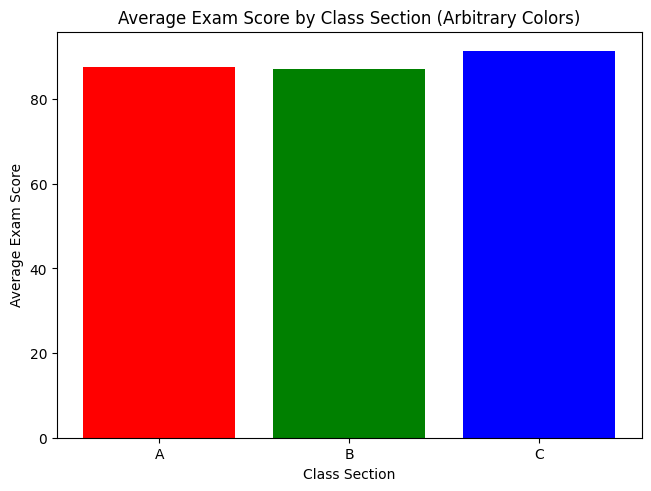

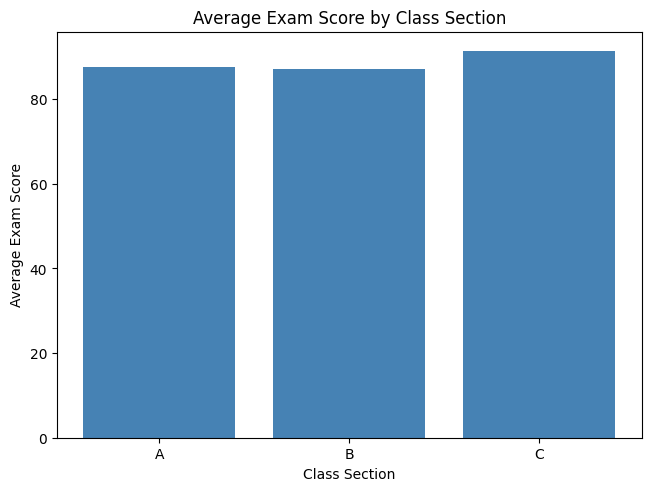

In [12]:
import matplotlib.pyplot as plt

section_means = students.groupby("class_section")["exam_score"].mean().reindex(["A", "B", "C"])

# --- Version 1: arbitrary colors (the mistake) ---
fig, ax = plt.subplots(layout="constrained")
ax.bar(section_means.index, section_means.values, color=["red", "green", "blue"])
ax.set_title("Average Exam Score by Class Section (Arbitrary Colors)")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
fig.savefig("chart_section_arbitrary_color.png")

# --- Version 2: deliberate, single consistent color ---
fig, ax = plt.subplots(layout="constrained")
ax.bar(section_means.index, section_means.values, color="steelblue")
ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
fig.savefig("chart_section_deliberate_color.png")

plt.show()

**Finding:** The arbitrary red/green/blue coloring in the first chart falsely implies 
a meaningful distinction (e.g., severity or status) between sections that doesn't 
exist in the data — class_section is an unordered category with no such hierarchy. 
The second chart uses a single consistent color instead, since no category here is 
being specifically highlighted or represents a genuinely ordered scale. Bars in both 
charts are kept in natural order (A, B, C) rather than sorted by score, since sorting 
would throw away the one piece of structure (section identity) the category already has.

### Step 8 — Self-Audit Kata

Findings paragraph citing three specific numbers, followed by an independent 
recomputation of each to confirm they match exactly.

In [13]:
import pandas as pd

# Freshly recompute all three numbers independently
r_study = students["study_hours_per_week"].corr(students["exam_score"])
r_sleep = students["sleep_hours_per_night"].corr(students["exam_score"])
mean_section_c = students.loc[students["class_section"] == "C", "exam_score"].mean()

print(f"study_hours vs exam_score correlation: r = {r_study:.3f}")
print(f"sleep_hours vs exam_score correlation: r = {r_sleep:.3f}")
print(f"Section C mean exam_score: {mean_section_c:.2f}")

study_hours vs exam_score correlation: r = 0.689
sleep_hours vs exam_score correlation: r = -0.022
Section C mean exam_score: 91.36


In [16]:
claimed_r_study = r_study
claimed_r_sleep = r_sleep
claimed_mean_c = mean_section_c

print(f"""
Findings: Study hours per week show a positive relationship with exam score 
(r = {claimed_r_study:.3f}), indicating students who study more tend to score higher. 

Sleep hours per night show no meaningful relationship with exam score 
(r = {claimed_r_sleep:.3f}), which is itself a real, reportable result rather than 
a failed chart. 

Among class sections, Section C has the highest average exam score 
at {claimed_mean_c:.2f}, consistent with the built-in section bonus in the dataset.
""")


Findings: Study hours per week show a positive relationship with exam score 
(r = 0.689), indicating students who study more tend to score higher. 

Sleep hours per night show no meaningful relationship with exam score 
(r = -0.022), which is itself a real, reportable result rather than 
a failed chart. 

Among class sections, Section C has the highest average exam score 
at 91.36, consistent with the built-in section bonus in the dataset.



In [15]:
audit_table = pd.DataFrame({
    "metric": ["study_hours vs exam_score (r)", "sleep_hours vs exam_score (r)", "Section C mean exam_score"],
    "claimed_in_paragraph": [claimed_r_study, claimed_r_sleep, claimed_mean_c],
    "freshly_recomputed": [
        students["study_hours_per_week"].corr(students["exam_score"]),
        students["sleep_hours_per_night"].corr(students["exam_score"]),
        students.loc[students["class_section"] == "C", "exam_score"].mean()
    ],
})
audit_table["match"] = audit_table["claimed_in_paragraph"] == audit_table["freshly_recomputed"]
audit_table

,metric,claimed_in_paragraph,freshly_recomputed,match
0,study_hours vs exam_score (r),0.689476,0.689476,True
1,sleep_hours vs exam_score (r),-0.021658,-0.021658,True
2,Section C mean exam_score,91.362632,91.362632,True


**Audit result:** All three claimed numbers match their freshly recomputed values 
exactly (`match = True` for all rows), since the paragraph itself was generated 
from the same variables via f-string rather than hand-typed from memory.